# NB04 — Arms Race Test (H1a)

**Purpose**: Test whether species-level anti-phage defense-system count scales
with per-species prophage burden after controlling for genome size and phylum.
This is the coevolutionary arms-race prediction: more phage pressure → more
defense investment.

**Analysis set**: 7,323 species with `no_genomes >= 5` (reliable core/accessory
calls).

**Statistical approach**:
1. **Marginal correlation**: Spearman ρ between `n_defense_systems` and
   `n_prophage_clusters` / `n_prophage_modules`.
2. **Partial correlation**: Spearman ρ on residuals after regressing out
   `log10(median_genome_size)` and phylum (one-hot).
3. **Negative binomial regression**: `n_defense_systems ~ n_prophage_clusters
   + log10(genome_size) + phylum`.
4. **Per-phylum consistency**: is the association universal across phyla?

**Note on prophage-burden saturation**: NB03 showed `n_prophage_modules` is
saturated at 7 modules for 35% of species (broad eggNOG description matching).
`n_prophage_clusters` is the primary continuous burden proxy for regression;
`n_prophage_modules` is a coarse categorical secondary test.

**Output**: `data/arms_race_results.tsv`, `figures/arms_race_scatter.png`,
`figures/partial_correlation_barplot.png`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.formula.api import glm as smf_glm
from statsmodels.genmod.families import NegativeBinomial

DATA_DIR = "../data"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load NB02 defense matrix and NB03 prophage burden; join

In [2]:
defense = pd.read_csv(os.path.join(DATA_DIR, "species_defense_matrix.tsv.gz"), sep="\t")
prophage = pd.read_csv(os.path.join(DATA_DIR, "species_prophage_burden.tsv.gz"), sep="\t")

print(f"Defense matrix: {len(defense):,} species")
print(f"Prophage burden: {len(prophage):,} species")

merged = defense.merge(prophage, on="gtdb_species_clade_id", how="inner")
print(f"Merged: {len(merged):,} species")

# Restrict to species with reliable pangenome (n_genomes >= 5) and non-null covariates
ge5 = merged.dropna(subset=["phylum", "median_genome_size", "no_genomes"]).copy()
ge5 = ge5[ge5["no_genomes"] >= 5].copy()
ge5["log10_genome_size"] = np.log10(ge5["median_genome_size"])
print(f"Analysis set (n_genomes >= 5, non-null covariates): {len(ge5):,} species")

Defense matrix: 27,626 species
Prophage burden: 27,702 species
Merged: 27,626 species
Analysis set (n_genomes >= 5, non-null covariates): 7,323 species


## 2. Marginal correlations

In [3]:
marginal_results = []
for burden_col in ["n_prophage_clusters", "n_prophage_modules"]:
    rho, p = spearmanr(ge5["n_defense_systems"], ge5[burden_col])
    marginal_results.append({
        "test": "Spearman (marginal)",
        "y": "n_defense_systems",
        "x": burden_col,
        "rho": rho,
        "p_value": p,
        "n": len(ge5),
    })
    print(f"Spearman(n_defense_systems, {burden_col}): rho = {rho:.4f}, p = {p:.3g}, n = {len(ge5):,}")

Spearman(n_defense_systems, n_prophage_clusters): rho = 0.6087, p = 0, n = 7,323
Spearman(n_defense_systems, n_prophage_modules): rho = 0.4502, p = 0, n = 7,323


## 3. Partial correlation (residualize on log10_genome_size + phylum)

Regress each variable on covariates via OLS (using pandas + numpy),
then Spearman on residuals.

In [4]:
from sklearn.linear_model import LinearRegression


def residualize(y, X):
    X_ = X.copy()
    model = LinearRegression().fit(X_, y)
    return y - model.predict(X_)


# Build design matrix: log10_genome_size + phylum one-hot
X_cov = pd.get_dummies(ge5["phylum"], drop_first=True, dtype=float)
X_cov["log10_genome_size"] = ge5["log10_genome_size"].values

partial_results = []
for burden_col in ["n_prophage_clusters", "n_prophage_modules"]:
    y_def_resid = residualize(ge5["n_defense_systems"].values.astype(float), X_cov.values)
    y_bur_resid = residualize(ge5[burden_col].values.astype(float), X_cov.values)
    rho, p = spearmanr(y_def_resid, y_bur_resid)
    partial_results.append({
        "test": "Spearman (partial: -log10_genome_size, -phylum)",
        "y": "n_defense_systems",
        "x": burden_col,
        "rho": rho,
        "p_value": p,
        "n": len(ge5),
    })
    print(f"Partial Spearman(n_defense_systems | log10_gs+phylum, {burden_col}): "
          f"rho = {rho:.4f}, p = {p:.3g}")

Partial Spearman(n_defense_systems | log10_gs+phylum, n_prophage_clusters): rho = 0.3013, p = 1.58e-153
Partial Spearman(n_defense_systems | log10_gs+phylum, n_prophage_modules): rho = 0.2625, p = 1.05e-115


## 4. Negative binomial regression

In [5]:
nb_data = ge5[[
    "n_defense_systems", "n_prophage_clusters",
    "log10_genome_size", "phylum"
]].copy()
nb_data["phylum"] = nb_data["phylum"].astype("category")

nb_model = smf_glm(
    "n_defense_systems ~ n_prophage_clusters + log10_genome_size + C(phylum)",
    data=nb_data,
    family=NegativeBinomial(alpha=1.0),
).fit()
print(nb_model.summary().tables[1])

nb_coefs = pd.DataFrame({
    "term": nb_model.params.index,
    "coef": nb_model.params.values,
    "std_err": nb_model.bse.values,
    "p_value": nb_model.pvalues.values,
})
nb_focal = nb_coefs[nb_coefs["term"].isin([
    "n_prophage_clusters", "log10_genome_size"
])]
print("\nFocal coefficients:")
print(nb_focal)

                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -3.4100      0.486     -7.013      0.000      -4.363      -2.457
C(phylum)[T.Actinomycetota]           0.0253      0.153      0.166      0.868      -0.275       0.325
C(phylum)[T.Aenigmatarchaeota]        0.5324      1.106      0.481      0.630      -1.636       2.701
C(phylum)[T.Altiarchaeota]            0.2841      0.796      0.357      0.721      -1.276       1.844
C(phylum)[T.Aquificota]               0.3295      1.106      0.298      0.766      -1.838       2.497
C(phylum)[T.Armatimonadota]           0.0933      0.359      0.260      0.795      -0.610       0.797
C(phylum)[T.Asgardarchaeota]          0.1974      0.564      0.350      0.726      -0.908       1.302
C(phylum)[T.Atribacterota]            0.3140      1.106      0.284      0.776     

## 5. Per-phylum consistency

Is the arms-race pattern universal across phyla? Compute per-phylum partial
Spearman ρ (residualizing on log10_genome_size within phylum).

In [6]:
phy_size = ge5["phylum"].value_counts()
big_phyla = phy_size[phy_size >= 100].index.tolist()

per_phylum = []
for phylum in big_phyla:
    sub = ge5[ge5["phylum"] == phylum]
    if len(sub) < 10:
        continue
    y_def_resid = residualize(
        sub["n_defense_systems"].values.astype(float),
        sub[["log10_genome_size"]].values,
    )
    y_bur_resid = residualize(
        sub["n_prophage_clusters"].values.astype(float),
        sub[["log10_genome_size"]].values,
    )
    rho, p = spearmanr(y_def_resid, y_bur_resid)
    per_phylum.append({
        "phylum": phylum,
        "n_species": len(sub),
        "rho": rho,
        "p_value": p,
    })
per_phylum_df = pd.DataFrame(per_phylum).sort_values("rho", ascending=False)
print(per_phylum_df)

              phylum  n_species       rho       p_value
8   Campylobacterota        102  0.530452  9.792885e-09
4          Bacillota        735  0.480879  8.446299e-44
1        Bacillota_A       1134  0.418968  2.016386e-49
6  Verrucomicrobiota        129  0.369393  1.647089e-05
5    Patescibacteria        191  0.342519  1.233710e-06
0     Pseudomonadota       2172  0.342281  9.587364e-61
7    Cyanobacteriota        124  0.308595  4.883389e-04
2       Bacteroidota        925  0.261498  6.294636e-16
3     Actinomycetota        803  0.184948  1.303464e-07


## 6. Figures

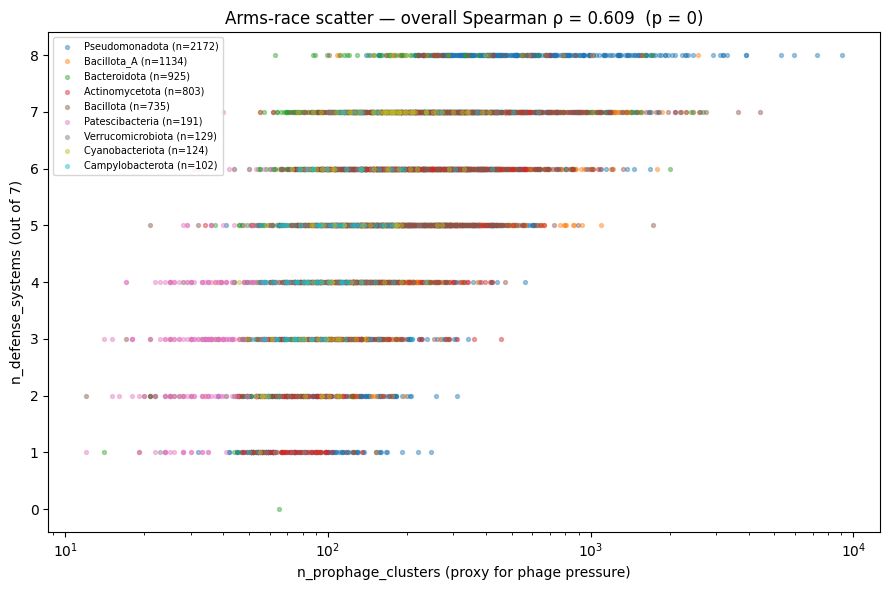

Saved: ../figures/arms_race_scatter.png


In [7]:
# Scatter: defense count vs prophage count, colored by phylum
fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(big_phyla)))
for phylum, color in zip(big_phyla, palette):
    sub = ge5[ge5["phylum"] == phylum]
    ax.scatter(sub["n_prophage_clusters"], sub["n_defense_systems"],
               s=8, alpha=0.4, label=f"{phylum} (n={len(sub)})", color=color)
ax.set_xlabel("n_prophage_clusters (proxy for phage pressure)")
ax.set_ylabel("n_defense_systems (out of 7)")
ax.set_xscale("log")
overall_rho, overall_p = spearmanr(ge5["n_defense_systems"], ge5["n_prophage_clusters"])
ax.set_title(f"Arms-race scatter — overall Spearman ρ = {overall_rho:.3f}  (p = {overall_p:.2g})")
ax.legend(loc="upper left", fontsize=7)
plt.tight_layout()
out_scatter = os.path.join(FIG_DIR, "arms_race_scatter.png")
plt.savefig(out_scatter, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {out_scatter}")

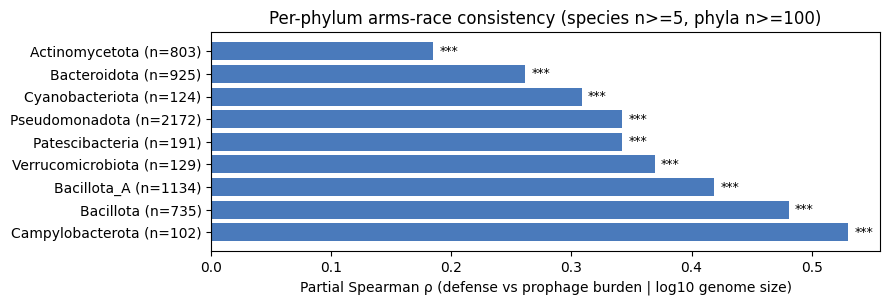

Saved: ../figures/partial_correlation_barplot.png


In [8]:
# Bar plot of per-phylum partial ρ
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(per_phylum_df))))
colors = ["#4a7abb" if r > 0 else "#c14a4a" for r in per_phylum_df["rho"]]
ax.barh(per_phylum_df["phylum"] + " (n=" + per_phylum_df["n_species"].astype(str) + ")",
        per_phylum_df["rho"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Partial Spearman ρ (defense vs prophage burden | log10 genome size)")
ax.set_title("Per-phylum arms-race consistency (species n>=5, phyla n>=100)")
for i, (rho, p) in enumerate(zip(per_phylum_df["rho"], per_phylum_df["p_value"])):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(rho + (0.005 if rho >= 0 else -0.005),
            i, f"{sig}",
            va="center", ha="left" if rho >= 0 else "right", fontsize=9)
plt.tight_layout()
out_bar = os.path.join(FIG_DIR, "partial_correlation_barplot.png")
plt.savefig(out_bar, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {out_bar}")

## 7. Save results

In [9]:
all_results = pd.concat([
    pd.DataFrame(marginal_results),
    pd.DataFrame(partial_results),
], ignore_index=True)
all_results.to_csv(os.path.join(DATA_DIR, "arms_race_results.tsv"), sep="\t", index=False)

per_phylum_df.to_csv(os.path.join(DATA_DIR, "arms_race_per_phylum.tsv"), sep="\t", index=False)

# NB regression summary
with open(os.path.join(DATA_DIR, "arms_race_nb_model.txt"), "w") as f:
    f.write(str(nb_model.summary()))

print("\nArtifacts written:")
for name in ["arms_race_results.tsv", "arms_race_per_phylum.tsv", "arms_race_nb_model.txt"]:
    p = os.path.join(DATA_DIR, name)
    print(f"  {p}  ({os.path.getsize(p):,} bytes)")


Artifacts written:
  ../data/arms_race_results.tsv  (460 bytes)
  ../data/arms_race_per_phylum.tsv  (570 bytes)
  ../data/arms_race_nb_model.txt  (10,558 bytes)


## Summary

See `data/arms_race_results.tsv` for the marginal and partial Spearman
results, `data/arms_race_per_phylum.tsv` for phylum consistency, and
`data/arms_race_nb_model.txt` for the negative binomial regression summary.

**Next**: `05_defense_syndromes.ipynb` — pairwise system co-occurrence
under a null model preserving marginal per-system prevalence and phylum
composition.